In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)

In [2]:
def debt_to_farm_asset_ratio(P, L, W, tcs=0.06, fds=0.07, fme=300.0):
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    lafa = (W / (pps * L)) - 1.0
    return max(0.0, -lafa)

def resulting_dfa_after_trade(P, L, W, x, xm=0.0, tcs=0.06, tcb=0.01, fds=0.07, fme=300.0):
    """Compute resulting DFA after farmland trade and mutual-fund investment."""
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    ppps = (1.0 + tcb) * P + fme
    if x < 0:
        ppps = pps
    L_post = L + x
    if L_post <= 0.0:
        return 0.0
    # Account for mutual-fund investment reducing effective wealth
    lafa12f = (W - xm - pps * L - ppps * x) / (pps * L_post)
    return max(0.0, -lafa12f)


In [6]:
from dataclasses import dataclass

import numpy as np

from dynprolib.pyfriendly import PortfolioConfig
from dynprolib.pyfriendly.portfolio_core import (
    apply_inverse_basis_chain,
    build_model_arrays,
    cartesian_grid,
    gauss_hermite_multinormal,
    linear_spline_basis,
    model_inverse_utility,
    model_utility,
    tensor_basis_interpolate,
    uniform_nodes,
)


@dataclass
class MutualFundConfig(PortfolioConfig):
    theta: float = 1.0
    gamma0: float = 0.057757
    EgRM: float = 1.073826
    n: tuple[int, int, int, int] = (7, 7, 5, 21)
    q: int = 21 #41
    q2: int = 5 #25
    m: tuple[int, int, int] = (3, 3, 3)
    var_cov: tuple[tuple[float, float, float], tuple[float, float, float], tuple[float, float, float]] = (
        (0.030186, 0.0, 0.0),
        (0.0, 0.017292, 0.0),
        (0.0, 0.0, 0.026941),
    
    )


def mutual_bounds_x(state, cfg):
    state = np.asarray(state, dtype=float)
    x_lower = np.full(state.shape[0], cfg.sminv[2], dtype=float) - state[:, 2]
    x_upper_land = np.full(state.shape[0], cfg.smaxv[2], dtype=float) - state[:, 2]
    sell_price = (1.0 - cfg.tcs) * state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    buy_price = (1.0 + cfg.tcb) * state[:, 1] + cfg.fme
    x_upper_debt = np.maximum(
        0.0,
        (state[:, 3] - (1.0 - cfg.dau) * sell_price * state[:, 2]) / (buy_price - cfg.dau * sell_price),
    )
    return x_lower, np.minimum(x_upper_land, x_upper_debt)


def mutual_bounds_xm(state, trade_x, cfg):
    state = np.asarray(state, dtype=float)
    trade_x = np.asarray(trade_x, dtype=float)
    if np.isscalar(trade_x):
        trade_x = np.full(state.shape[0], float(trade_x), dtype=float)
    if np.all(state[:, 2] + trade_x < 1.0):
        xml = state[:, 3].copy()
        xmu = state[:, 3].copy()
        return xml, xmu

    s2bs = (1.0 + cfg.tcb) * state[:, 1] + cfg.fme
    sell_mask = trade_x < 0
    s2bs[sell_mask] = (1.0 - cfg.tcs) * state[sell_mask, 1] + (1.0 - cfg.fds) * cfg.fme
    s2v = (1.0 - cfg.tcs) * state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    at = state[:, 3] - s2v * state[:, 2]
    xml = np.zeros(state.shape[0], dtype=float)
    xmu = np.maximum(0.0, at - s2bs * trade_x + cfg.dau * s2v * (state[:, 2] + trade_x))
    return xml, xmu


def mutual_transition_next_state(state, trade_x, mutual_x, shocks, cfg, sminv, smaxv):
    state = np.asarray(state, dtype=float)
    trade_x = np.asarray(trade_x, dtype=float)
    mutual_x = np.asarray(mutual_x, dtype=float)
    shocks = np.asarray(shocks, dtype=float)
    next_state = np.zeros_like(state, dtype=float)

    growth_r = np.exp(cfg.beta0 + cfg.beta1 * np.log(state[:, 0]) + shocks[:, 0])
    growth_p = np.exp(cfg.alpha0 + cfg.alpha1 * np.log(state[:, 1]) + cfg.alpha2 * np.log(state[:, 0]) + shocks[:, 1])
    growth_m = np.exp(cfg.gamma0 + shocks[:, 2])

    next_state[:, 0] = np.clip(growth_r, sminv[0], smaxv[0])
    next_state[:, 1] = np.clip(growth_p, sminv[1], smaxv[1])
    next_state[:, 2] = state[:, 2] + trade_x

    sell_price_now = (1.0 - cfg.tcs) * state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    sell_price_next = (1.0 - cfg.tcs) * next_state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    buy_price = (1.0 + cfg.tcb) * state[:, 1] + cfg.fme
    sell_mask = trade_x < 0
    buy_price[sell_mask] = (1.0 - cfg.tcs) * state[sell_mask, 1] + (1.0 - cfg.fds) * cfg.fme

    equity_now = state[:, 3] - sell_price_now * state[:, 2]
    low_land = next_state[:, 2] < 1.0

    # MATLAB gstate.m uses vector if-logic, equivalent to all(low_land) in NumPy.
    if np.all(low_land):
        next_state[:, 3] = cfg.EgRM * state[:, 3]
        return next_state

    cash_after_cost = equity_now - buy_price * trade_x - cfg.cost * next_state[:, 2] - mutual_x
    rate_high_land = np.full(state.shape[0], cfg.rp, dtype=float)
    rate_high_land[cash_after_cost < 0] = cfg.rn
    wealth_high_land = (1.0 + rate_high_land) * cash_after_cost + next_state[:, 0] * next_state[:, 2] + sell_price_next * next_state[:, 2] + growth_m * mutual_x

    next_state[:, 3] = wealth_high_land
    return next_state


def mutual_value_function(state, coeffs, t, controls, cfg, arrays, shock_nodes, shock_weights):
    state = np.asarray(state, dtype=float)
    controls = np.asarray(controls, dtype=float)
    trade_x = controls[:, 0]
    mutual_x = controls[:, 1]
    value = np.zeros(state.shape[0], dtype=float)
    use_crra = bool(getattr(cfg, "CRRA", True))

    for k in range(shock_nodes.shape[0]):
        shocks = np.tile(shock_nodes[k], (state.shape[0], 1))
        next_state = mutual_transition_next_state(state, trade_x, mutual_x, shocks, cfg, arrays['sminv'], arrays['smaxv'])
        v_k = np.zeros(state.shape[0], dtype=float)
        low_land = next_state[:, 2] < 1.0

        # MATLAB valuefw.m uses vector if-logic, equivalent to all(low_land) in NumPy.
        if np.all(low_land):
            continuation_wealth = (cfg.EgRM ** (cfg.T - t + 1)) * state[:, 3]
            v_k[:] = model_utility(continuation_wealth, cfg.b, cfg.theta, use_crra)
        else:
            gf4 = next_state[:, 3]
            if coeffs is None or coeffs.size == 0:
                v_k[:] = model_utility(gf4, cfg.b, cfg.theta, use_crra)
            else:
                nbri = np.where(gf4 > 0)[0]
                if nbri.size > 0:
                    gm4 = np.minimum(next_state[nbri, 3], arrays['smaxv'][3])
                    gd = next_state[nbri, 3] - gm4
                    g_eval = next_state[nbri].copy()
                    g_eval[:, 3] = gm4
                    phi = [
                        linear_spline_basis(int(arrays['n'][d]), float(arrays['smin'][d]), float(arrays['smax'][d]), g_eval[:, d])
                        for d in range(len(arrays['n']))
                    ]
                    v_interp = tensor_basis_interpolate(phi, coeffs.reshape(-1, 1)).reshape(-1)
                    tw = model_inverse_utility(v_interp, cfg.b, cfg.theta, use_crra)
                    v_nbri = v_interp.copy()
                    over_cap = next_state[nbri, 3] > arrays['smaxv'][3]
                    if np.any(over_cap):
                        v_nbri[over_cap] = model_utility(
                            tw[over_cap] + ((1.0 + cfg.rp) ** (cfg.T - t)) * gd[over_cap],
                            cfg.b,
                            cfg.theta,
                            use_crra,
                        )
                    v_k[nbri] = v_nbri
                neg = np.where(gf4 <= 0)[0]
                if neg.size > 0:
                    v_k[neg] = model_utility(
                        ((1.0 + cfg.rn) ** (cfg.T - t)) * gf4[neg],
                        cfg.b,
                        cfg.theta,
                        use_crra,
                    )

        value += v_k * shock_weights[k]
    return value


def mutual_vmaxhm(state, coeffs, t, xqi, cfg, arrays, shock_nodes, shock_weights):
    xml, xmu = mutual_bounds_xm(state, xqi, cfg)
    nn = state.shape[0]
    xmq = np.zeros((cfg.q2, nn), dtype=float)
    vxq2 = np.zeros((cfg.q2, nn), dtype=float)
    gap = (xmu - xml) / (cfg.q2 - 1)

    for qj in range(cfg.q2):
        xmqj = xml + gap * qj
        controls = np.column_stack([np.asarray(xqi, dtype=float), xmqj])
        vxq2[qj, :] = mutual_value_function(state, coeffs, t, controls, cfg, arrays, shock_nodes, shock_weights)
        xmq[qj, :] = xmqj

    ind = np.argmax(vxq2, axis=0)
    j = np.arange(nn)
    xmqi = xmq[ind, j]
    vqi = vxq2[ind, j]
    return xmqi, vqi


def mutual_vmaxh(state, coeffs, t, cfg, arrays, shock_nodes, shock_weights):
    xl, xu = mutual_bounds_x(state, cfg)
    nn = state.shape[0]
    vxq = np.zeros((cfg.q + 2, nn), dtype=float)
    xq = np.zeros((cfg.q + 2, nn), dtype=float)
    xmq = np.zeros((cfg.q + 2, nn), dtype=float)
    gap = (xu - xl) / (cfg.q - 1)

    for qi in range(cfg.q + 2):
        if qi == 0:
            xqi = np.zeros(nn, dtype=float)
        elif qi == 1:
            xqi = -state[:, 2]
        else:
            xqi = xl + gap * (qi - 2)
        xmqi, vqi = mutual_vmaxhm(state, coeffs, t, xqi, cfg, arrays, shock_nodes, shock_weights)
        xq[qi, :] = xqi
        xmq[qi, :] = xmqi
        vxq[qi, :] = vqi

    ind = np.argmax(vxq, axis=0)
    j = np.arange(nn)
    x = xq[ind, j]
    xm = xmq[ind, j]
    v = vxq[ind, j]
    return x, xm, v


def solve_mutual_coefficients(cfg):
    arrays = build_model_arrays(cfg)
    n = arrays['n']
    shock_nodes, shock_weights = gauss_hermite_multinormal(arrays['m'], arrays['Ee'], arrays['VarCov'])
    state_nodes = [uniform_nodes(int(n[d]), float(arrays['smin'][d]), float(arrays['smax'][d])) for d in range(len(n))]
    inverse_basis = [
        np.linalg.inv(linear_spline_basis(int(n[d]), float(arrays['smin'][d]), float(arrays['smax'][d]), state_nodes[d]))
        for d in range(len(n))
    ]
    state_grid = cartesian_grid(state_nodes)

    n_points = state_grid.shape[0]
    coeffs_over_time = np.zeros((n_points, cfg.T), dtype=float)
    active_idx = np.where(state_grid[:, 3] > 1.0)[0]
    active_states = state_grid[active_idx]
    coeffs = None
    use_crra = bool(getattr(cfg, "CRRA", True))

    for t in range(cfg.T, cfg.t1 - 1, -1):
        _, _, value = mutual_vmaxh(active_states, coeffs, t, cfg, arrays, shock_nodes, shock_weights)
        value_full = np.full(n_points, model_utility(0.0, cfg.b, cfg.theta, use_crra), dtype=float)
        value_full[active_idx] = value
        coeffs = apply_inverse_basis_chain(inverse_basis, value_full.reshape(-1, 1)).reshape(-1)
        coeffs_over_time[:, t - 1] = coeffs

    return coeffs_over_time


def mutual_policy_grid(copt, cfg, t=0, Lt=600.0, Rt=365.0, wealth_levels=None):
    arrays = build_model_arrays(cfg)
    shock_nodes, shock_weights = gauss_hermite_multinormal(arrays['m'], arrays['Ee'], arrays['VarCov'])
    p_vals = np.arange(cfg.sminv[1], cfg.smaxv[1] + 5.0, 5.0, dtype=float)
    if wealth_levels is None:
        w_vals = np.arange(400_000.0, 600_000.0, 1_000_000.0, dtype=float)
    else:
        w_vals = np.asarray(wealth_levels, dtype=float)

    coeffs = None if t == cfg.T else copt[:, t]
    x_policy = np.zeros((p_vals.size, w_vals.size), dtype=float)
    xm_policy = np.zeros((p_vals.size, w_vals.size), dtype=float)

    for wi, wealth_t in enumerate(w_vals):
        state = np.zeros((p_vals.size, len(arrays['n'])), dtype=float)
        state[:, 0] = Rt
        state[:, 1] = p_vals
        state[:, 2] = Lt
        state[:, 3] = wealth_t
        x_opt, xm_opt, _ = mutual_vmaxh(state, coeffs, t, cfg, arrays, shock_nodes, shock_weights)
        x_policy[:, wi] = x_opt
        xm_policy[:, wi] = xm_opt

    return {"P": p_vals, "W": w_vals, "X": x_policy, "XM": xm_policy, "arrays": arrays}


class MutualFundModel:
    def __init__(self, config=None):
        self.config = config or MutualFundConfig()

    def transition(self, R, P, L, W, x, xm, eps1, eps2, eps3):
        state = np.array([[R, P, L, W]], dtype=float)
        shocks = np.array([[eps1, eps2, eps3]], dtype=float)
        next_state = mutual_transition_next_state(
            state=state,
            trade_x=np.array([x], dtype=float),
            mutual_x=np.array([xm], dtype=float),
            shocks=shocks,
            cfg=self.config,
            sminv=np.array(self.config.sminv, dtype=float),
            smaxv=np.array(self.config.smaxv, dtype=float),
        )
        return tuple(next_state[0])

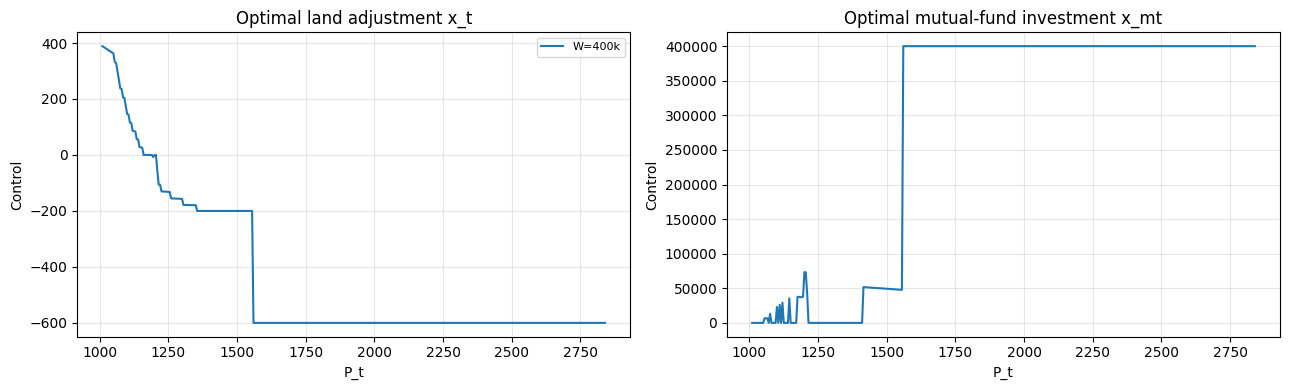

In [4]:

# Build a mutual-fund policy slice and visualize x_t and x_mt against P_t.
model=MutualFundModel()
model.config.Ee = (0.0, 0.0, 0.0)
model.config.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)
copt = solve_mutual_coefficients(model.config)
policy = mutual_policy_grid(copt, model.config, t=model.config.T - 1, Lt=600.0, Rt=365.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
wealth_labels = [f'W={int(w/1000)}k' for w in policy['W']]

for wi, label in enumerate(wealth_labels):
    axes[0].plot(policy['P'], policy['X'][:, wi], label=label)
    axes[1].plot(policy['P'], policy['XM'][:, wi], label=label)

axes[0].set_title('Optimal land adjustment x_t')
axes[1].set_title('Optimal mutual-fund investment x_mt')
for ax in axes:
    ax.set_xlabel('P_t')
    ax.set_ylabel('Control')
    ax.grid(True, alpha=0.3)
axes[0].legend(loc='best', fontsize=8)
fig.tight_layout()
plt.show()

In [5]:
policy['P']


array([1010., 1015., 1020., 1025., 1030., 1035., 1040., 1045., 1050.,
       1055., 1060., 1065., 1070., 1075., 1080., 1085., 1090., 1095.,
       1100., 1105., 1110., 1115., 1120., 1125., 1130., 1135., 1140.,
       1145., 1150., 1155., 1160., 1165., 1170., 1175., 1180., 1185.,
       1190., 1195., 1200., 1205., 1210., 1215., 1220., 1225., 1230.,
       1235., 1240., 1245., 1250., 1255., 1260., 1265., 1270., 1275.,
       1280., 1285., 1290., 1295., 1300., 1305., 1310., 1315., 1320.,
       1325., 1330., 1335., 1340., 1345., 1350., 1355., 1360., 1365.,
       1370., 1375., 1380., 1385., 1390., 1395., 1400., 1405., 1410.,
       1415., 1420., 1425., 1430., 1435., 1440., 1445., 1450., 1455.,
       1460., 1465., 1470., 1475., 1480., 1485., 1490., 1495., 1500.,
       1505., 1510., 1515., 1520., 1525., 1530., 1535., 1540., 1545.,
       1550., 1555., 1560., 1565., 1570., 1575., 1580., 1585., 1590.,
       1595., 1600., 1605., 1610., 1615., 1620., 1625., 1630., 1635.,
       1640., 1645.,

In [4]:
import pandas as pd

# Table-8 replication for the model with mutual funds.
# Paper setup uses: initial wealth $1,000,000, x-grid q=41, mutual-fund grid q2=25.
rng = np.random.default_rng(42)
n_sims = 500
n_years = 10

model=MutualFundModel()
cfg = model.config
cfg.Ee = (0.0, 0.0, 0.0)
cfg.q = 41
cfg.q2 = 25
cfg.theta = 1.0
cfg.CRRA = False   # Set to False to run CARA utility mode.
cfg.m = (3, 3, 3)
cfg.dau = 0.45 #Credit limit parameter from paper. 
cfg.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)

# Reuse copt when possible; this is the main runtime bottleneck.
cfg_key = (
    cfg.n,
    cfg.q,
    cfg.q2,
    cfg.m,
    cfg.T,
    cfg.t1,
    cfg.Ee,
    cfg.var_cov,
    cfg.theta,
    cfg.b,
    cfg.dau,
    bool(cfg.CRRA),
)
if "_mutual_copt_cache" not in globals():
    _mutual_copt_cache = {}
if cfg_key not in _mutual_copt_cache:
    print(f"Solving coefficients with q={cfg.q}, q2={cfg.q2}...")
    _mutual_copt_cache[cfg_key] = solve_mutual_coefficients(cfg)
    print("Done solving.")
else:
    print(f"Using cached coefficients (q={cfg.q}, q2={cfg.q2})")
copt = _mutual_copt_cache[cfg_key]

arrays = build_model_arrays(cfg)
shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])
mean_e = np.asarray(cfg.Ee, dtype=float)
cov_e = np.asarray(cfg.var_cov, dtype=float)

# Table-8 initial state from paper.
initial_wealth = 1_000_000.0
states = np.zeros((n_sims, 4), dtype=float)
states[:, 0] = 365.0        # R_0
states[:, 1] = 1775.0       # P_0
states[:, 2] = 600.0        # L_0
states[:, 3] = initial_wealth

summary_rows = [
    {
        "Year": 0,
        "Expected net wealth ($)": states[:, 3].mean(),
        "St. dev. of net wealth ($)": np.nan,
        "Expected farmland (acres)": states[:, 2].mean(),
        "Prob. of exiting farming": 0.0,
    }
]

for year in range(1, n_years + 1):
    # MATLAB pathT.m: yr=0..years-1, c1=copt(:,yr+1), and t passed to vmaxh is yr.
    yr_idx = year - 1
    coeffs_t = copt[:, yr_idx]
    t_eval = yr_idx

    # Follow MATLAB "ini" set: active farming states are L >= sminv(3)-1 and W > 0.
    active_mask = (states[:, 2] >= (arrays["sminv"][2] - 1.0)) & (states[:, 3] > 0.0)
    active_idx = np.where(active_mask)[0]

    next_states = states.copy()

    if active_idx.size > 0:
        active_states = states[active_idx]
        x_opt, xm_opt, _ = mutual_vmaxh(
            active_states, coeffs_t, t_eval, cfg, arrays, shock_nodes, shock_weights
        )

        shocks = rng.multivariate_normal(mean=mean_e, cov=cov_e, size=active_idx.size)
        next_active = mutual_transition_next_state(
            active_states, x_opt, xm_opt, shocks, cfg, arrays["sminv"], arrays["smaxv"]
        )
        next_states[active_idx] = next_active

    # Follow MATLAB "outi" transition: all non-active states are absorbing out-of-farming states.
    out_idx = np.where(~active_mask)[0]
    if out_idx.size > 0:
        next_states[out_idx, 2] = 0.0
        positive_wealth = next_states[out_idx, 3] >= 0.0
        next_states[out_idx[positive_wealth], 3] = cfg.EgRM * next_states[out_idx[positive_wealth], 3]
        next_states[out_idx[~positive_wealth], 3] = (1.0 + cfg.rn) * next_states[out_idx[~positive_wealth], 3]

    states = next_states
    exited = (states[:, 2] < 1.0) | (states[:, 3] <= 0.0)

    summary_rows.append(
        {
            "Year": year,
            "Expected net wealth ($)": states[:, 3].mean(),
            "St. dev. of net wealth ($)": states[:, 3].std(ddof=1),
            "Expected farmland (acres)": states[:, 2].mean(),
            "Prob. of exiting farming": exited.mean(),
        }
    )

mutual_estimates_df = pd.DataFrame(summary_rows)
table_display = mutual_estimates_df.copy()
table_display["Expected net wealth ($)"] = table_display["Expected net wealth ($)"].map(lambda v: f"{v:,.0f}")
table_display["St. dev. of net wealth ($)"] = table_display["St. dev. of net wealth ($)"].map(
    lambda v: "-" if pd.isna(v) else f"{v:,.0f}"
)
table_display["Expected farmland (acres)"] = table_display["Expected farmland (acres)"].map(lambda v: f"{v:,.0f}")
table_display["Prob. of exiting farming"] = table_display["Prob. of exiting farming"].map(lambda v: f"{v:.3f}")

table_display

Solving coefficients with q=41, q2=25...


/Users/nicklasjensen/Desktop/Økonomi/DynPro 2026/Dynamic-Programming-Project/dynprolib/pyfriendly/portfolio_core.py:407: RuntimeWarning: overflow encountered in exp
  return np.where(yv >= b, 1.0 - np.exp(-theta * yv), u_b + slope * (yv - b))


KeyboardInterrupt: 

In [12]:
# Use the already formatted table and makecell-ready headers, then save to LaTeX.
metric_makecell = {
    "Expected net wealth ($)": r"\makecell{Expected net\\wealth (\$)}",
    "St. dev. of net wealth ($)": r"\makecell{St. dev. of\\net wealth (\$)}",
    "Expected farmland (acres)": r"\makecell{Expected farmland\\(acres)}",
    "Prob. of exiting farming": r"\makecell{Prob. of exiting\\farming}",
}
table8_makecell = table_display.rename(columns=metric_makecell)

latex_str = table8_makecell.to_latex(
    index=False,
    escape=False,  # keep \makecell commands
    column_format="cccccc",
    caption="Table 8-style policy table (model with mutual fund)",
    label="tab:table8_mutual_makecell",
)

tex_path = "table8_makecell.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)

print(f"Saved LaTeX table to: {tex_path}")
print("Add \\usepackage{makecell} to your LaTeX preamble.")

NameError: name 'table_display' is not defined

In [10]:
import numpy as np
import pandas as pd

# Table 7-style policy table for the model WITH mutual funds.
# Uses the same (P, W) states as Finished_model and reports optimal controls from the mutual solver.

cfg_table7_mutual = MutualFundConfig()
cfg_table7_mutual.theta = 1.0
cfg_table7_mutual.CRRA = True   # Set to False to run CARA utility mode.
cfg_table7_mutual.n = (7, 7, 5, 21)
cfg_table7_mutual.q = 41
cfg_table7_mutual.q2 = 25
cfg_table7_mutual.m = (3, 3, 3)
cfg_table7_mutual.T = 19
cfg_table7_mutual.t1 = 1
cfg_table7_mutual.Ee = (0.0, 0.0, 0.0)
cfg_table7_mutual.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)

cache_key = (
    cfg_table7_mutual.n,
    cfg_table7_mutual.q,
    cfg_table7_mutual.q2,
    cfg_table7_mutual.m,
    cfg_table7_mutual.T,
    cfg_table7_mutual.t1,
    cfg_table7_mutual.theta,
    cfg_table7_mutual.b,
    cfg_table7_mutual.dau,
    bool(cfg_table7_mutual.CRRA),
    cfg_table7_mutual.Ee,
    cfg_table7_mutual.var_cov,
)
if "_mutual_copt_cache" not in globals():
    _mutual_copt_cache = {}
if cache_key not in _mutual_copt_cache:
    print("Solving mutual-fund coefficients for Table 7-style policy table...")
    _mutual_copt_cache[cache_key] = solve_mutual_coefficients(cfg_table7_mutual)
    print("Done solving.")
else:
    print("Using cached mutual-fund coefficients for Table 7-style policy table.")

copt_table7_mutual = _mutual_copt_cache[cache_key]
arrays_m = build_model_arrays(cfg_table7_mutual)
shock_nodes_m, shock_weights_m = gauss_hermite_multinormal(arrays_m["m"], arrays_m["Ee"], arrays_m["VarCov"])

def debt_to_farm_asset_ratio(P, L, W, tcs=0.06, fds=0.07, fme=300.0):
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    lafa = (W / (pps * L)) - 1.0
    return max(0.0, -lafa)

def resulting_dfa_after_trade(P, L, W, x, xm=0.0, tcs=0.06, tcb=0.01, fds=0.07, fme=300.0):
    """Compute resulting DFA after farmland trade and mutual-fund investment."""
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    ppps = (1.0 + tcb) * P + fme
    if x < 0:
        ppps = pps
    L_post = L + x
    if L_post <= 0.0:
        return 0.0
    # Account for mutual-fund investment reducing effective wealth
    lafa12f = (W - xm - pps * L - ppps * x) / (pps * L_post)
    return max(0.0, -lafa12f)

Lt = 600.0
Rt = 365.0
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
rows = []
for P in prices:
    for W in wealth_levels:
        state = np.array([[Rt, P, Lt, W]], dtype=float)
        x_opt, xm_opt, _ = mutual_vmaxh(
            state,
            copt_table7_mutual[:, 0],
            0,
            cfg_table7_mutual,
            arrays_m,
            shock_nodes_m,
            shock_weights_m,
        )
        x_star = float(x_opt[0])
        xm_star = float(xm_opt[0])
        rows.append(
            {
                "Current farmland price ($)": int(P),
                "Net wealth ($)": int(W),
                "Debt-to-farm-asset ratio": debt_to_farm_asset_ratio(P, Lt, W),
                "Optimal farmland transaction (acres)": x_star,
                "Optimal mutual-fund investment ($)": xm_star,
                "Resulting debt-to-farm-asset ratio": resulting_dfa_after_trade(P, Lt, W, x_star, xm_star),
            }
        )

table7_with_mutual = pd.DataFrame(rows)
display_table7_with_mutual = table7_with_mutual.copy()
display_table7_with_mutual["Net wealth ($)"] = display_table7_with_mutual["Net wealth ($)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Debt-to-farm-asset ratio"] = display_table7_with_mutual["Debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")
display_table7_with_mutual["Optimal farmland transaction (acres)"] = display_table7_with_mutual["Optimal farmland transaction (acres)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Optimal mutual-fund investment ($)"] = display_table7_with_mutual["Optimal mutual-fund investment ($)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Resulting debt-to-farm-asset ratio"] = display_table7_with_mutual["Resulting debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")

print("Table 7-style policy table - Model with mutual fund (simulation-based policy evaluation, theta=1)")
display(display_table7_with_mutual)


Solving mutual-fund coefficients for Table 7-style policy table...
Done solving.
Table 7-style policy table - Model with mutual fund (simulation-based policy evaluation, theta=1)


,Current farmland price ($),Net wealth ($),Debt-to-farm-asset ratio,Optimal farmland transaction (acres),Optimal mutual-fund investment ($),Resulting debt-to-farm-asset ratio
0,1500,"400,000",0.61,-200,"49,330",0.48
1,1500,"600,000",0.41,0,"209,652",0.61
2,1500,"1,000,000",0.01,0,"347,990",0.36
3,1775,"400,000",0.66,-600,"400,000",0.00
4,1775,"600,000",0.49,-200,"137,362",0.41
5,1775,"1,000,000",0.14,0,"405,906",0.49


In [13]:
# Use the already formatted table and makecell-ready headers, then save to LaTeX.
table7_makecell = display_table7_with_mutual.rename(columns=metric_makecell)

latex_str = table7_makecell.to_latex(
    index=False,
    escape=False,  # keep \makecell commands
    column_format="cccccc",
    caption="Table 7-style policy table (model with mutual fund)",
    label="tab:table7_mutual_makecell",
)

tex_path = "table7_makecell.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)

print(f"Saved LaTeX table to: {tex_path}")
print("Add \\usepackage{makecell} to your LaTeX preamble.")

Saved LaTeX table to: table7_makecell.tex
Add \usepackage{makecell} to your LaTeX preamble.


Computing sensitivity analysis for rho/dau = 0.5 and 0.7...
Multiple scenarios across prices and wealth levels.

Sensitivity Analysis: rho/dau = 0.5 vs 0.7


,rho/dau,Price,Wealth,Initial DFA,Farmland trade (acres),Mutual fund investment ($),Final DFA
0,0.5,"$1,500","$400,000",0.605,-200,"46,650",0.477
1,0.5,"$1,500","$600,000",0.408,0,"93,300",0.500
2,0.5,"$1,500","$1,000,000",0.013,0,"369,975",0.378
3,0.5,"$1,775","$400,000",0.658,-600,"400,000",0.000
4,0.5,"$1,775","$600,000",0.487,-200,"157,875",0.432
5,0.5,"$1,775","$1,000,000",0.144,0,"415,750",0.500
6,0.7,"$1,500","$400,000",0.605,-200,"49,330",0.481
7,0.7,"$1,500","$600,000",0.408,0,"209,652",0.615
8,0.7,"$1,500","$1,000,000",0.013,0,"347,990",0.357
9,0.7,"$1,775","$400,000",0.658,-600,"400,000",0.000



Saved figure: rho_dau_comparison.png


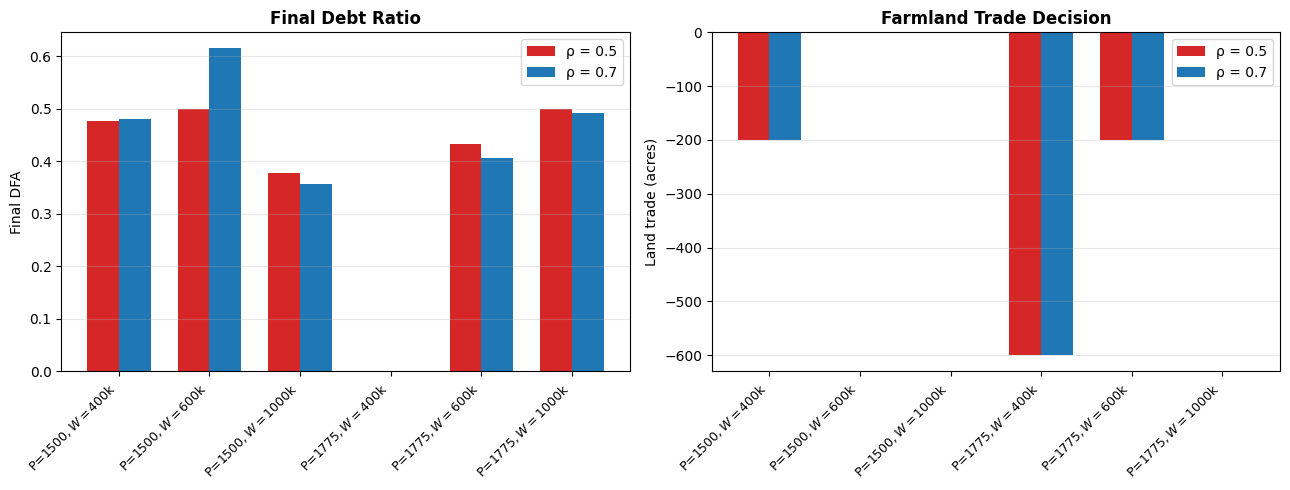

Saved LaTeX table: rho_dau_comparison.tex


In [17]:
# Sensitivity Analysis: compare rho/dau = 0.5 against the baseline rho/dau = 0.7
# Multiple scenarios like normal Table 7: prices and wealth levels

compare_daus = [0.5, float(cfg_table7_mutual.dau)]
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
reference_Rt = 365.0
reference_Lt = 600.0

comparison_rows = []

print("Computing sensitivity analysis for rho/dau = 0.5 and 0.7...")
print("Multiple scenarios across prices and wealth levels.\n")

for dau in compare_daus:
    if np.isclose(dau, float(cfg_table7_mutual.dau)):
        cfg_sensitivity = cfg_table7_mutual
        copt_sensitivity = copt_table7_mutual
        arrays_sens = arrays_m
        shock_nodes_sens = shock_nodes_m
        shock_weights_sens = shock_weights_m
    else:
        cfg_sensitivity = MutualFundConfig()
        cfg_sensitivity.dau = float(dau)
        cfg_sensitivity.Ee = (0.0, 0.0, 0.0)
        cfg_sensitivity.var_cov = (
            (0.030186, 0.0, 0.0),
            (0.0, 0.017292, 0.0),
            (0.0, 0.0, 0.026941),
        )
        cache_key_sens = (
            cfg_sensitivity.n,
            cfg_sensitivity.q,
            cfg_sensitivity.q2,
            cfg_sensitivity.m,
            cfg_sensitivity.T,
            cfg_sensitivity.t1,
            cfg_sensitivity.theta,
            cfg_sensitivity.b,
            cfg_sensitivity.dau,
            bool(cfg_sensitivity.CRRA),
            cfg_sensitivity.Ee,
            cfg_sensitivity.var_cov,
        )
        if cache_key_sens not in _mutual_copt_cache:
            print(f"  Solving for rho/dau={dau:.1f}...")
            _mutual_copt_cache[cache_key_sens] = solve_mutual_coefficients(cfg_sensitivity)
        copt_sensitivity = _mutual_copt_cache[cache_key_sens]
        arrays_sens = build_model_arrays(cfg_sensitivity)
        shock_nodes_sens, shock_weights_sens = gauss_hermite_multinormal(
            arrays_sens["m"], arrays_sens["Ee"], arrays_sens["VarCov"]
        )

    for price in prices:
        for wealth in wealth_levels:
            state = np.array([[reference_Rt, price, reference_Lt, wealth]], dtype=float)
            x_opt, xm_opt, _ = mutual_vmaxh(
                state,
                copt_sensitivity[:, 0],
                0,
                cfg_sensitivity,
                arrays_sens,
                shock_nodes_sens,
                shock_weights_sens,
            )
            x_star = float(x_opt[0])
            xm_star = float(xm_opt[0])
            comparison_rows.append({
                "rho/dau": f"{dau:.1f}",
                "Price": int(price),
                "Wealth": int(wealth),
                "Initial DFA": debt_to_farm_asset_ratio(price, reference_Lt, wealth),
                "Farmland trade (acres)": x_star,
                "Mutual fund investment ($)": xm_star,
                "Final DFA": resulting_dfa_after_trade(price, reference_Lt, wealth, x_star, xm_star),
            })

comparison_df = pd.DataFrame(comparison_rows)

display_table = comparison_df.copy()
display_table["Price"] = display_table["Price"].map(lambda v: f"${v:,.0f}")
display_table["Wealth"] = display_table["Wealth"].map(lambda v: f"${v:,.0f}")
display_table["Initial DFA"] = display_table["Initial DFA"].map(lambda v: f"{v:.3f}")
display_table["Farmland trade (acres)"] = display_table["Farmland trade (acres)"].map(lambda v: f"{v:,.0f}")
display_table["Mutual fund investment ($)"] = display_table["Mutual fund investment ($)"].map(lambda v: f"{v:,.0f}")
display_table["Final DFA"] = display_table["Final DFA"].map(lambda v: f"{v:.3f}")

print("=" * 100)
print("Sensitivity Analysis: rho/dau = 0.5 vs 0.7")
print("=" * 100)
display(display_table)

# Create grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Final DFA comparison
plot_data = comparison_df.pivot_table(
    index=["Price", "Wealth"],
    columns="rho/dau",
    values="Final DFA"
).reset_index()
x_labels = [f"P=${int(p)}, W=${int(w)//1000}k" for p, w in zip(plot_data["Price"], plot_data["Wealth"])]
x_pos = np.arange(len(x_labels))
width = 0.35

axes[0].bar(x_pos - width/2, plot_data["0.5"], width, label="ρ = 0.5", color="#d62728")
axes[0].bar(x_pos + width/2, plot_data["0.7"], width, label="ρ = 0.7", color="#1f77b4")
axes[0].set_title("Final Debt Ratio", fontweight="bold")
axes[0].set_ylabel("Final DFA")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Farmland trade comparison
plot_data2 = comparison_df.pivot_table(
    index=["Price", "Wealth"],
    columns="rho/dau",
    values="Farmland trade (acres)"
).reset_index()

axes[1].bar(x_pos - width/2, plot_data2["0.5"], width, label="ρ = 0.5", color="#d62728")
axes[1].bar(x_pos + width/2, plot_data2["0.7"], width, label="ρ = 0.7", color="#1f77b4")
axes[1].set_title("Farmland Trade Decision", fontweight="bold")
axes[1].set_ylabel("Land trade (acres)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("rho_dau_comparison.png", dpi=300, bbox_inches="tight")
print("\nSaved figure: rho_dau_comparison.png")
plt.show()

latex_table = display_table.rename(columns={
    "rho/dau": r"$\rho$",
    "Price": "Price",
    "Wealth": "Wealth",
    "Initial DFA": "Initial DFA",
    "Farmland trade (acres)": "Land trade",
    "Mutual fund investment ($)": "MF invest.",
    "Final DFA": "Final DFA",
})
latex_str = latex_table.to_latex(
    index=False,
    escape=False,
    column_format="ccccccc",
    caption="Sensitivity Analysis: Effect of lowering credit limit parameter $\rho$ from 0.7 to 0.5",
    label="tab:rho_dau_sensitivity",
)
tex_path = "rho_dau_comparison.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)
print(f"Saved LaTeX table: {tex_path}")

Computing CRRA vs CARA utility comparison...
Using baseline rho/dau = 0.7 for both.
CRRA theta = 1; CARA theta = 1/W_ref with W_ref=$600,000 -> 1.66667e-06

  Solving for CARA utility...
CRRA vs CARA Utility Comparison (rho/dau = 0.7, CARA calibrated at W_ref)


,Utility,Price,Wealth,Initial DFA,Farmland trade (acres),Mutual fund investment ($),Final DFA
0,CRRA,"$1,500","$400,000",0.605,-200,"49,330",0.481
1,CRRA,"$1,500","$600,000",0.408,0,"221,985",0.627
2,CRRA,"$1,500","$1,000,000",0.013,0,"347,990",0.357
3,CRRA,"$1,775","$400,000",0.658,-600,"400,000",0.000
4,CRRA,"$1,775","$600,000",0.487,-200,"183,150",0.465
5,CRRA,"$1,775","$1,000,000",0.144,0,"487,088",0.561
6,CARA,"$1,500","$400,000",0.605,-600,"400,000",0.000
7,CARA,"$1,500","$600,000",0.408,-600,"600,000",0.000
8,CARA,"$1,500","$1,000,000",0.013,-600,"1,000,000",0.000
9,CARA,"$1,775","$400,000",0.658,-600,"400,000",0.000



Saved figure: crra_cara_comparison.png


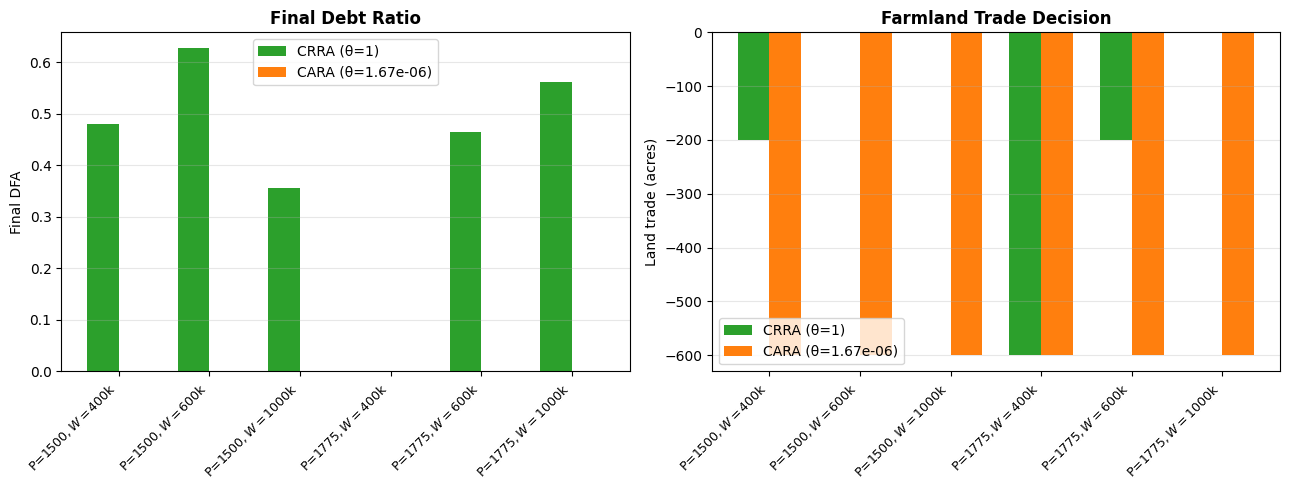

Saved LaTeX table: crra_cara_comparison.tex


In [29]:
# CRRA vs CARA Utility Comparison
# Compare risk preferences with CARA calibrated to match CRRA(log) ARA at a reference wealth.

compare_crra = [True, False]  # True=CRRA, False=CARA
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
reference_Rt = 365.0
reference_Lt = 600.0

# Comparable calibration: match absolute risk aversion at W_ref
# CRRA with theta=1 (log utility) has ARA = 1/W, CARA has ARA = theta.
cara_ref_wealth = 600_000.0
theta_crra = 1.0
theta_cara = 1.0 / cara_ref_wealth

crra_cara_rows = []

print("Computing CRRA vs CARA utility comparison...")
print("Using baseline rho/dau = 0.7 for both.")
print(f"CRRA theta = {theta_crra:.6g}; CARA theta = 1/W_ref with W_ref=${cara_ref_wealth:,.0f} -> {theta_cara:.6g}\n")

for use_crra in compare_crra:
    cfg_utility = MutualFundConfig()
    cfg_utility.CRRA = use_crra
    cfg_utility.theta = theta_crra if use_crra else theta_cara
    cfg_utility.Ee = (0.0, 0.0, 0.0)
    cfg_utility.var_cov = (
        (0.030186, 0.0, 0.0),
        (0.0, 0.017292, 0.0),
        (0.0, 0.0, 0.026941),
    )

    cache_key_utility = (
        cfg_utility.n,
        cfg_utility.q,
        cfg_utility.q2,
        cfg_utility.m,
        cfg_utility.T,
        cfg_utility.t1,
        cfg_utility.theta,
        cfg_utility.b,
        cfg_utility.dau,
        bool(cfg_utility.CRRA),
        cfg_utility.Ee,
        cfg_utility.var_cov,
    )

    if cache_key_utility not in _mutual_copt_cache:
        utility_label = "CRRA" if use_crra else "CARA"
        print(f"  Solving for {utility_label} utility...")
        _mutual_copt_cache[cache_key_utility] = solve_mutual_coefficients(cfg_utility)

    copt_utility = _mutual_copt_cache[cache_key_utility]
    arrays_utility = build_model_arrays(cfg_utility)
    shock_nodes_utility, shock_weights_utility = gauss_hermite_multinormal(
        arrays_utility["m"], arrays_utility["Ee"], arrays_utility["VarCov"]
    )

    for price in prices:
        for wealth in wealth_levels:
            state = np.array([[reference_Rt, price, reference_Lt, wealth]], dtype=float)
            x_opt, xm_opt, _ = mutual_vmaxh(
                state,
                copt_utility[:, 0],
                0,
                cfg_utility,
                arrays_utility,
                shock_nodes_utility,
                shock_weights_utility,
            )
            x_star = float(x_opt[0])
            xm_star = float(xm_opt[0])
            crra_cara_rows.append({
                "Utility": "CRRA" if use_crra else "CARA",
                "Price": int(price),
                "Wealth": int(wealth),
                "Initial DFA": debt_to_farm_asset_ratio(price, reference_Lt, wealth),
                "Farmland trade (acres)": x_star,
                "Mutual fund investment ($)": xm_star,
                "Final DFA": resulting_dfa_after_trade(price, reference_Lt, wealth, x_star, xm_star),
            })

crra_cara_df = pd.DataFrame(crra_cara_rows)

display_crra_cara = crra_cara_df.copy()
display_crra_cara["Price"] = display_crra_cara["Price"].map(lambda v: f"${v:,.0f}")
display_crra_cara["Wealth"] = display_crra_cara["Wealth"].map(lambda v: f"${v:,.0f}")
display_crra_cara["Initial DFA"] = display_crra_cara["Initial DFA"].map(lambda v: f"{v:.3f}")
display_crra_cara["Farmland trade (acres)"] = display_crra_cara["Farmland trade (acres)"].map(lambda v: f"{v:,.0f}")
display_crra_cara["Mutual fund investment ($)"] = display_crra_cara["Mutual fund investment ($)"].map(lambda v: f"{v:,.0f}")
display_crra_cara["Final DFA"] = display_crra_cara["Final DFA"].map(lambda v: f"{v:.3f}")

print("=" * 100)
print("CRRA vs CARA Utility Comparison (rho/dau = 0.7, CARA calibrated at W_ref)")
print("=" * 100)
display(display_crra_cara)

# Create grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Final DFA comparison
plot_data = crra_cara_df.pivot_table(
    index=["Price", "Wealth"],
    columns="Utility",
    values="Final DFA"
).reset_index()
x_labels = [f"P=${int(p)}, W=${int(w)//1000}k" for p, w in zip(plot_data["Price"], plot_data["Wealth"])]
x_pos = np.arange(len(x_labels))
width = 0.35

axes[0].bar(x_pos - width/2, plot_data["CRRA"], width, label=f"CRRA (θ={theta_crra:g})", color="#2ca02c")
axes[0].bar(x_pos + width/2, plot_data["CARA"], width, label=f"CARA (θ={theta_cara:.2e})", color="#ff7f0e")
axes[0].set_title("Final Debt Ratio", fontweight="bold")
axes[0].set_ylabel("Final DFA")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Farmland trade comparison
plot_data2 = crra_cara_df.pivot_table(
    index=["Price", "Wealth"],
    columns="Utility",
    values="Farmland trade (acres)"
).reset_index()

axes[1].bar(x_pos - width/2, plot_data2["CRRA"], width, label=f"CRRA (θ={theta_crra:g})", color="#2ca02c")
axes[1].bar(x_pos + width/2, plot_data2["CARA"], width, label=f"CARA (θ={theta_cara:.2e})", color="#ff7f0e")
axes[1].set_title("Farmland Trade Decision", fontweight="bold")
axes[1].set_ylabel("Land trade (acres)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("crra_cara_comparison.png", dpi=300, bbox_inches="tight")
print("\nSaved figure: crra_cara_comparison.png")
plt.show()

latex_table_crra = display_crra_cara.rename(columns={
    "Utility": "Utility",
    "Price": "Price",
    "Wealth": "Wealth",
    "Initial DFA": "Initial DFA",
    "Farmland trade (acres)": "Land trade",
    "Mutual fund investment ($)": "MF invest.",
    "Final DFA": "Final DFA",
})
latex_str_crra = latex_table_crra.to_latex(
    index=False,
    escape=False,
    column_format="cccccccc",
    caption="Utility Function Comparison: CRRA vs CARA preferences on optimal decisions (CARA calibrated by ARA match at W_ref)",
    label="tab:crra_cara_comparison",
)
tex_path_crra = "crra_cara_comparison.tex"
with open(tex_path_crra, "w") as f:
    f.write(latex_str_crra)
print(f"Saved LaTeX table: {tex_path_crra}")

In [23]:
# Diagnostic: inspect CRRA vs CARA results and flag odd rows
if 'crra_cara_df' in globals():
    df = crra_cara_df.copy()
    # Show raw numeric values for inspection
    pd.set_option('display.float_format', lambda x: f"{x:.6f}")
    print('Full CRRA/CARA table (raw values):')
    display(df.reset_index(drop=True))

    # Flag zero trades/investments
    df['FT_zero'] = np.isclose(df['Farmland trade (acres)'], 0.0)
    df['MF_zero'] = np.isclose(df['Mutual fund investment ($)'], 0.0)

    print('\nRows with no land trade or no mutual-fund investment:')
    display(df[(df['FT_zero']) | (df['MF_zero'])][['Utility','Price','Wealth','Farmland trade (acres)','Mutual fund investment ($)','Final DFA','FT_zero','MF_zero']])

    # Show specific rows 6,7,11 (1-based indexing) if present
    for r in [6,7,11]:
        idx = r - 1
        if idx < len(df):
            print(f"\nRow {r} (1-based):")
            display(df.iloc[[idx]][['Utility','Price','Wealth','Farmland trade (acres)','Mutual fund investment ($)','Final DFA']])
else:
    print('crra_cara_df not found in kernel. Run the CRRA/CARA comparison cell first.')


Full CRRA/CARA table (raw values):


,Utility,Price,Wealth,Initial DFA,Farmland trade (acres),Mutual fund investment ($),Final DFA
0,CRRA,1500,400000,0.605289,-200.000000,49330.000000,0.480950
1,CRRA,1500,600000,0.407934,0.000000,221985.000000,0.626983
2,CRRA,1500,1000000,0.013223,0.000000,347990.000000,0.356611
3,CRRA,1775,400000,0.657681,-600.000000,400000.000000,0.000000
4,CRRA,1775,600000,0.486521,-200.000000,183150.000000,0.464891
5,CRRA,1775,1000000,0.144202,0.000000,487087.500000,0.561050
6,CARA,1500,400000,0.605289,0.000000,0.000000,0.605289
7,CARA,1500,600000,0.407934,0.000000,0.000000,0.407934
8,CARA,1500,1000000,0.013223,-69.998419,182862.049787,0.087173
9,CARA,1775,400000,0.657681,-186.610692,39619.324237,0.552364



Rows with no land trade or no mutual-fund investment:


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA,FT_zero,MF_zero
1,CRRA,1500,600000,0.000000,221985.000000,0.626983,True,False
2,CRRA,1500,1000000,0.000000,347990.000000,0.356611,True,False
5,CRRA,1775,1000000,0.000000,487087.500000,0.561050,True,False
6,CARA,1500,400000,0.000000,0.000000,0.605289,True,True
7,CARA,1500,600000,0.000000,0.000000,0.407934,True,True
10,CARA,1775,600000,-200.000000,0.000000,0.229782,False,True



Row 6 (1-based):


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA
5,CRRA,1775,1000000,0.000000,487087.500000,0.561050



Row 7 (1-based):


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA
6,CARA,1500,400000,0.000000,0.000000,0.605289



Row 11 (1-based):


,Utility,Price,Wealth,Farmland trade (acres),Mutual fund investment ($),Final DFA
10,CARA,1775,600000,-200.000000,0.000000,0.229782


In [25]:
# Diagnostic grid search for CARA problematic cases (use cached copt lookup)
from itertools import product

if 'crra_cara_df' in globals():
    cases = [
        {'Price':1500.0,'Wealth':400_000.0},
        {'Price':1500.0,'Wealth':600_000.0},
        {'Price':1775.0,'Wealth':600_000.0},
    ]
    use_crra = False
    theta = 1.0
    b = 60000.0
    dau = 0.7

    # Find matching cached copt
    cache_key_utility = None
    for k in _mutual_copt_cache.keys():
        try:
            if k[6] == theta and k[7] == b and k[8] == dau and (k[9] is False or k[9] == use_crra):
                cache_key_utility = k
                break
        except Exception:
            continue
    if cache_key_utility is None:
        raise RuntimeError('No matching cached copt found for CARA settings')

    copt_utility = _mutual_copt_cache[cache_key_utility]
    arrays_utility = build_model_arrays(MutualFundConfig())
    shock_nodes_utility, shock_weights_utility = gauss_hermite_multinormal(arrays_utility['m'], arrays_utility['Ee'], arrays_utility['VarCov'])

    for case in cases:
        P = case['Price']
        W = case['Wealth']
        state = np.array([[reference_Rt, P, reference_Lt, W]], dtype=float)
        xl, xu = mutual_bounds_x(state, MutualFundConfig())
        trade_grid = np.linspace(xl[0], xu[0], num=9)
        best_val = -1e99
        best_control = (0.0, 0.0)
        for tx in trade_grid:
            tx_arr = np.array([tx])
            xml, xmu = mutual_bounds_xm(state, tx_arr, MutualFundConfig())
            xm_grid = np.linspace(xml[0], xmu[0], num=9)
            for xm in xm_grid:
                controls = np.array([[tx, xm]])
                val = mutual_value_function(state, copt_utility, 0, controls, MutualFundConfig(), arrays_utility, shock_nodes_utility, shock_weights_utility)[0]
                if val > best_val:
                    best_val = float(val)
                    best_control = (float(tx), float(xm))
        zero_controls = np.array([[0.0, 0.0]])
        zero_val = mutual_value_function(state, copt_utility, 0, zero_controls, MutualFundConfig(), arrays_utility, shock_nodes_utility, shock_weights_utility)[0]
        print(f"Case P={int(P)}, W={int(W)} (CARA): best_val={best_val:.6f} at control={best_control}; zero_val={zero_val:.6f}")
        if np.isclose(best_control[0], 0.0) and np.isclose(best_control[1], 0.0):
            print("  -> Grid search confirms zero control is best within sampled bounds.")
        else:
            print("  -> Grid search found a better control; consider using finer grid or inspecting bounds.")
else:
    print('crra_cara_df not available; run comparison cell first.')


ValueError: operands could not be broadcast together with shapes (27,3) (1,2) 

In [24]:
# Quick inspect cache keys and shapes
for k, v in _mutual_copt_cache.items():
    try:
        print(k, np.shape(v))
    except Exception as e:
        print('key', k, 'error:', e)


((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, np.float64(0.3), True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.5, True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 41, 25, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.7, True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.7, True, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
((7, 7, 5, 21), 21, 5, (3, 3, 3), 19, 1, 1.0, 60000.0, 0.7, False, (0.0, 0.0, 0.0), ((0.030186, 0.0, 0.0), (0.0, 0.017292, 0.0), (0.0, 0.0, 0.026941))) (5145, 19)
